In [ ]:
import numpy as np

def make_web(n,k,kmin=0):
    #den her funktion laver et helt random netværk af n sider, hvor hver side har mellem kmin og k links til andre sider.
    

    # Input: n og k er ikke-negative heltal
    # Output: web er en dictionary med n nøgler.
    # Værdien af hver nøgle er en mængde, der er en delmængde af nøglerne.
    
    assert(k < n), "k skal være mindre end n (da man ikke kan linke til sig selv)"
    assert(kmin <= k), "kmin skal være mindre end eller lig med k"
    keys = [i for i in range(n)]# laver en liste fra [0, 1, 2, ..., n-1]
    web = dict()
    for j in keys:
        #for hver hjemmeside finder vi hvor mange hjemmesider den skal linke til (numlinks) og derefter vælger vi hvilke hjemmesider den skal linke til (web[j])
        numlinks = np.random.randint(kmin,k) # generér et tilfældigt tal mellem kmin og k
        web[j] = set() # starter med en tom mængde for hver hjemmeside
        links = []
        for _ in range(numlinks): # nu vælger vi numlinks tilfældige hjemmesider at linke til
            link = np.random.choice(keys) # vælg en tilfældig hjemmeside fra keys
            if link != j: # sørg for at hjemmesiden ikke linker til sig selv
                links.append(int(link)) # tilføj den valgte hjemmeside til links-listen
        web[j] = set(links) # konverter links-listen til en mængde og tildel den til web[j]
    return web

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_graph(web):
    
    # Input: netværk som dictionary
    # Output: Netværk visualiseret som graf

    G = nx.DiGraph()
    for node, links in web.items():
        G.add_node(node)
        for link in links:
            G.add_edge(node, link)

    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color='lightblue', font_size=8, arrows=True)

    # INDSÆT KODE HER

    plt.show()

In [ ]:
#opgave 9
def surf_step(web, startpage):
    
    # Input: Et netværk som dictionary og en start side
    # Output: Sandsynlighedsfordeling som dictionary for næste hjemmeside
    
    distribution=dict() # laver en tom dictionary til at gemme sandsynlighedsfordelingen

    for page, links in web.items(): # for hver hjemmeside og dens links i web-dictionaryen
        if links == set(): # hvis hjemmesiden ikke har nogen links, så skal den have en ligelig fordeling over alle sider
            distribution[page] = [1/len(web) for i in range(len(web))] # fordel sandsynligheden ligeligt over alle sider fx laver den [0, 0, 0, 0, 0] -> [1/5, 1/5, 1/5, 1/5, 1/5]
        else: # hvis hjemmesiden har links, så skal den fordele sandsynligheden ligeligt over de sider den linker til
            distribution[page] = [0 for i in range(len(web))] # starter med at lave [0, 0, 0, 0, 0] for hver hjemmeside
            for link in links:
                distribution[page][link] += 1/len(links) # her taget den fx [0, 1, 0, 1, 0] og laver den til [0, 1/2, 0, 1/2, 0] hvis der er 2 links

    
    return distribution[startpage] # returner sandsynlighedsfordelingen for den startside vi har valgt

In [ ]:
#opgave 10
def random_surf(web, n):

    # Input: Et netværk som dictionary og antallet af skridt i random surf simuleringen
    # Output: PageRank-værdier for hver side som en dictionary
    ranking=dict()
    starts = [i for i in web.keys()] # en liste over alle hjemmesider
    start_page = np.random.choice(starts) # vælg en random hjemmeside at starte på
    for i in range(n):
        distribution = surf_step(web, start_page) # start med at find sandsynlighedsfordelingen for den startside vi har valgt
        indices = np.arange(len(distribution))
        start_page = np.random.choice(indices, p=distribution) # vælg en ny startside baseret på sandsynlighedsfordelingen
        if start_page not in ranking.keys(): # hver gang vi lander på en hjemmeside, så tæller vi det i ranking-dictionaryen
            ranking[int(start_page)] = 1
        else:
            ranking[int(start_page)] +=1
    for i in ranking.keys():
        ranking[i] = ranking[i]/n # til sidst dividerer vi hver tælling i ranking-dictionaryen med n for at få en sandsynlighedsfordeling over hvor ofte vi lander på hver hjemmeside
    
    # INDSÆT KODE HER

    return ranking

In [6]:
web = make_web(10, 6)

In [7]:
random_surf(web, 10000000)

{8: 0.1267419,
 7: 0.169064,
 3: 0.0986884,
 4: 0.0422958,
 2: 0.0563455,
 1: 0.168888,
 9: 0.1267264,
 5: 0.0985205,
 0: 0.0564139,
 6: 0.0563156}

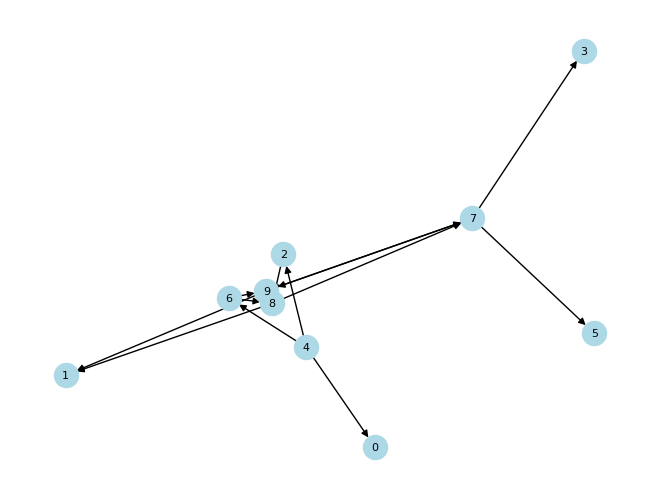

In [8]:
visualize_graph(web)